     sepal.length  sepal.width
1             7.6          3.0
3             6.7          2.5
5             5.9          3.2
7             6.3          2.5
8             6.3          2.7
..            ...          ...
110           6.0          2.7
111           6.8          3.2
113           6.4          2.9
114           5.6          2.9
119           5.7          2.9

[78 rows x 2 columns]
layer     sepal.length  sepal.width
0            7.1          3.0
1            5.5          2.4
2            5.6          2.5
3            6.7          3.1
5            5.8          2.7
6            6.2          2.2
9            5.9          3.0
10           6.5          3.0
11           6.1          3.0
12           5.6          2.8
13           6.9          3.1
15           5.5          2.5
16           6.3          3.3
17           5.5          2.4
18           5.8          2.7
19           6.7          3.3
20           6.4          3.1
22           6.7          3.0
23           6.5          3.0

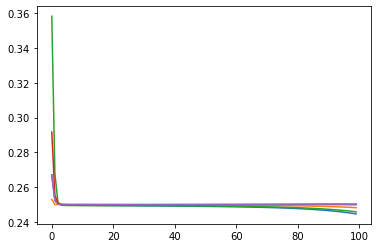

In [2]:
import numpy as np
import pandas as pd
from typing import Tuple
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split

# read_data, get_df_shape, data_split are the same as HW3
def read_data(filename: str) -> pd.DataFrame:
    d = pd.read_csv(filename)
    df = pd.DataFrame(data=d)
    return df

def extract_features_label(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series]:
    # Filter the dataframe to include only Setosa and Virginica rows
    
    # (###NET1### i)
    #filtered_df = df[df['variety'].isin(['Versicolor', 'Virginica'])]
    #features = filtered_df[['sepal.length', 'sepal.width']] # accuracy .54
    #labels = filtered_df['variety'].map({'Versicolor': 0, 'Virginica': 1})
    
    # Extract the required features and labels from the filtered dataframe
    
    # (###NET2### ii)
    #filtered_df = df[df['variety'].isin(['Setosa', 'Virginica'])]
    #features = filtered_df[['petal.length', 'petal.width']] # accuracy 1.0
    #labels = filtered_df['variety'].map({'Setosa': 0, 'Virginica': 1})
    
    # (tests I ran for NET1)
    #features = filtered_df[['sepal.length', 'petal.width']] # accuracy 1.0
    #features = filtered_df[['petal.length', 'sepal.width']] # accuracy 1.0
    
    # (###NET4### four features i) 
    filtered_df = df[df['variety'].isin(['Versicolor', 'Virginica'])]
    features = filtered_df[['sepal.length', 'sepal.width','petal.length', 'petal.width']] # accuracy .54
    labels = filtered_df['variety'].map({'Versicolor': 0, 'Virginica': 1})
    
    # (###NET4### four features ii)
    #filtered_df = df[df['variety'].isin(['Setosa', 'Virginica'])]
    #features = filtered_df[['sepal.length', 'sepal.width','petal.length', 'petal.width']] # accuracy 1.0
    #labels = filtered_df['variety'].map({'Setosa': 0, 'Virginica': 1})

    return features, labels

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def function_derivative(z):
    fd = sigmoid(z)
    return fd * (1 - fd)

class NN:
    def __init__(self, features, hidden_layers, hidden_neurons, output_neurons, learning_rate):
        self.features = features
        self.hidden_layers = hidden_layers
        self.hidden_neurons = hidden_neurons
        self.output_neurons = output_neurons
        self.learning_rate = learning_rate
        
        # Initialize weights and biases
        self.weights = []
        self.biases = []
        (self.weights).append((np.random.randn(self.features,self.hidden_neurons)))
        (self.biases).append((np.zeros((self.hidden_neurons))))
        for _ in range(hidden_layers):
            (self.weights).append((np.random.randn(self.hidden_neurons, self.hidden_neurons)))
            (self.biases).append((np.zeros((self.hidden_neurons))))

        # Additional weight and bias for the last layer
        (self.weights).append((np.random.randn(self.hidden_neurons, self.output_neurons)))
        (self.biases).append((np.zeros((self.output_neurons))))


    def train(self, X, t, epochs=1000):
        costs = []
        if(self.features==2):
            X = X[['sepal.length', 'sepal.width']]
        elif(self.features==3):
            X = X[['sepal.length', 'sepal.width','petal.length']]
        print(X)
        for epoch in range(epochs):
            layer_outputs = []
            net_inputs = []
            layer_outputs.append(X)
            O = []
            for i in range(self.hidden_layers + 1):  # +1 for the output layer
                net_input = layer_outputs[i].dot(self.weights[i]) + self.biases[i]
                net_inputs.append(net_input)
                layer_output = sigmoid(net_input)
                layer_outputs.append(layer_output)
                O = sigmoid(net_input)
                

            gradients = []
            errors = []

            # Calculate output layer error and gradient
            output_error = layer_outputs[-1] - t
            output_gradient = function_derivative(net_inputs[-1])
            errors.append(output_error)
            gradients.append(output_error * output_gradient)

            # Backpropagation for hidden layers
            for i in range(self.hidden_layers, 0, -1):
                error = gradients[-1].dot(self.weights[i].T)
                gradient = function_derivative(net_inputs[i - 1])
                errors.append(error)
                gradients.append(error * gradient)

            # Reverse the lists to match the layer order
            errors.reverse()
            gradients.reverse()

            # Update weights and biases
            for i in range(self.hidden_layers + 1):
                self.weights[i] -= self.learning_rate * layer_outputs[i].T.dot(gradients[i])
                self.biases[i] -= self.learning_rate * np.sum(gradients[i], axis=0)

            # Calculate and store the cost
            if epoch % 10 == 0:
                loss = np.square(np.subtract(t, O)).mean()
                costs.append(loss)

        return costs

    def predict(self, X):
        if(self.features==2):
            X = X[['sepal.length', 'sepal.width']]
        elif(self.features==3):
            X = X[['sepal.length', 'sepal.width','petal.length']]
        layer_outputs = []
        net_inputs = []
        layer_outputs.append(X)
        O = []
        for i in range(self.hidden_layers + 1):  # +1 for the output layer
            net_input = (layer_outputs[i]).dot(self.weights[i]) + self.biases[i]
            net_inputs.append(net_input)
            layer_output = sigmoid(net_input)
            layer_outputs.append(layer_output)
            O = sigmoid(net_input)
        print('layer',layer_outputs[0])
        print('w',self.weights[0])
        print('b',self.biases[0])
        #print(O)
        return (O > 0.5).astype(int)


if __name__ == "__main__":
    def accuracy(t, y_pred):
        accuracy = np.sum(t == y_pred) / len(t)
        return accuracy

    # Read the data
    train_df = read_data("/Users/panda/Downloads/iris_training_data.csv")
    test_df = read_data("/Users/panda/Downloads/iris_testing_data.csv")
    
    X, t =  extract_features_label(train_df)
    X_test, t_test = extract_features_label(test_df)
    t = t.values.reshape([len(t),1])
    t_test = t_test.values.reshape([len(t_test),1])

nn = NN(features=2, hidden_layers=3, hidden_neurons=5, output_neurons=1, learning_rate=0.01)

# Train the network
cost = nn.train(X, t)

# Make predictions on the test data
y_pred = nn.predict(X_test)

# Evaluate the accuracy
acc = accuracy(t_test, y_pred)
print('Accuracy:', acc)#, 'Cost:', cost

plt.plot(cost)
plt.show()
